Online loading failed, fallback to synthetic signal: <urlopen error [Errno 11004] getaddrinfo failed>
Core Controlled Experiment


C:\Users\wsssc\AppData\Local\Temp\ipykernel_36240\2645745861.py:43: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  'timestamp': pd.date_range(start='2026-07-01', periods=n_samples, freq='T'),



=== Direct AI (No Filter) Evaluation Report ===
Threshold: 0.000013
False alarms: 619 / 619 (100.00%)
Detection rate: 4 / 4 (100.00%)

=== EE-Enhanced AI (0.05Hz, 4th-order) Evaluation Report ===
Threshold: 0.001936
False alarms: 381 / 619 (61.55%)
Detection rate: 4 / 4 (100.00%)

Ablation Study 1: Cutoff Frequency

=== Cutoff = 0.02 Hz Evaluation Report ===
Threshold: 0.000247
False alarms: 341 / 619 (55.09%)
Detection rate: 4 / 4 (100.00%)

=== Cutoff = 0.05 Hz Evaluation Report ===
Threshold: 0.001936
False alarms: 381 / 619 (61.55%)
Detection rate: 4 / 4 (100.00%)

=== Cutoff = 0.1 Hz Evaluation Report ===
Threshold: 0.003069
False alarms: 614 / 619 (99.19%)
Detection rate: 4 / 4 (100.00%)

=== Cutoff = 0.2 Hz Evaluation Report ===
Threshold: 0.001613
False alarms: 617 / 619 (99.68%)
Detection rate: 4 / 4 (100.00%)

Ablation Study 2: Filter Order

=== 2th-order Evaluation Report ===
Threshold: 0.000661
False alarms: 555 / 619 (89.66%)
Detection rate: 4 / 4 (100.00%)

=== 4th-order

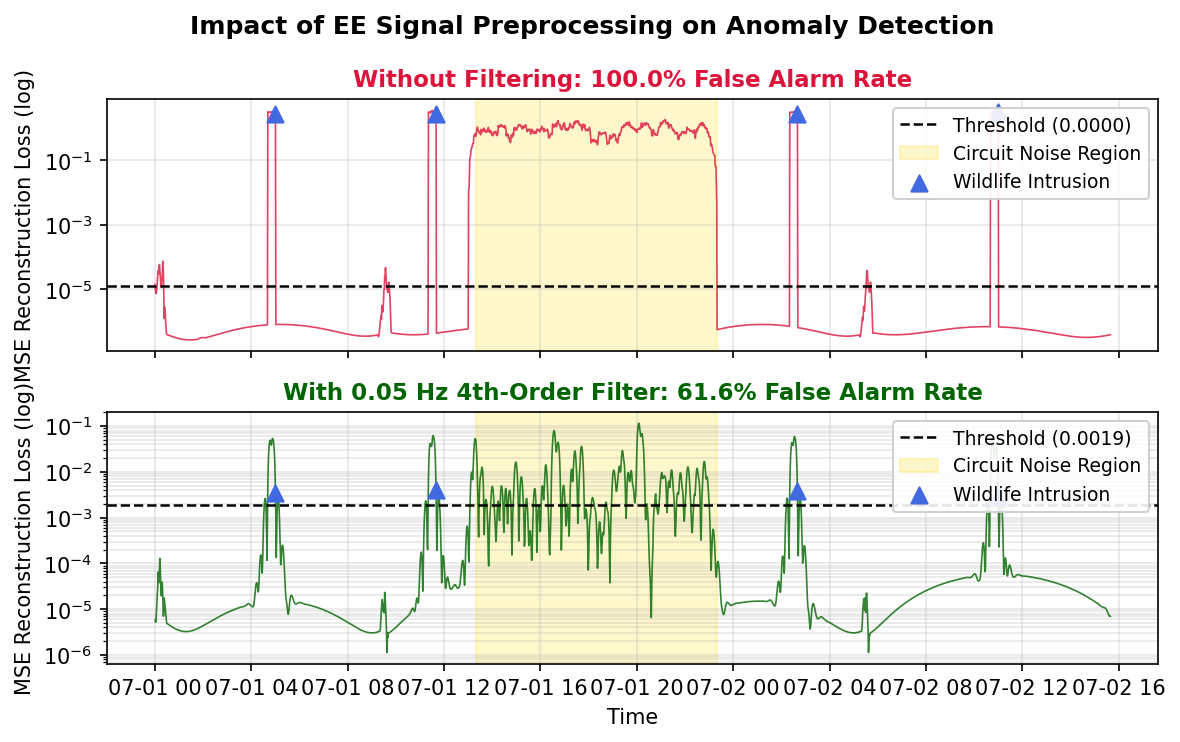

C:\Users\wsssc\AppData\Local\Temp\ipykernel_36240\2645745861.py:272: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(freq, 20*np.log10(np.abs(h)), label=f'{fc} Hz')
C:\Users\wsssc\AppData\Local\Temp\ipykernel_36240\2645745861.py:285: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(freq, 20*np.log10(np.abs(h)), label=f'{n}th order')


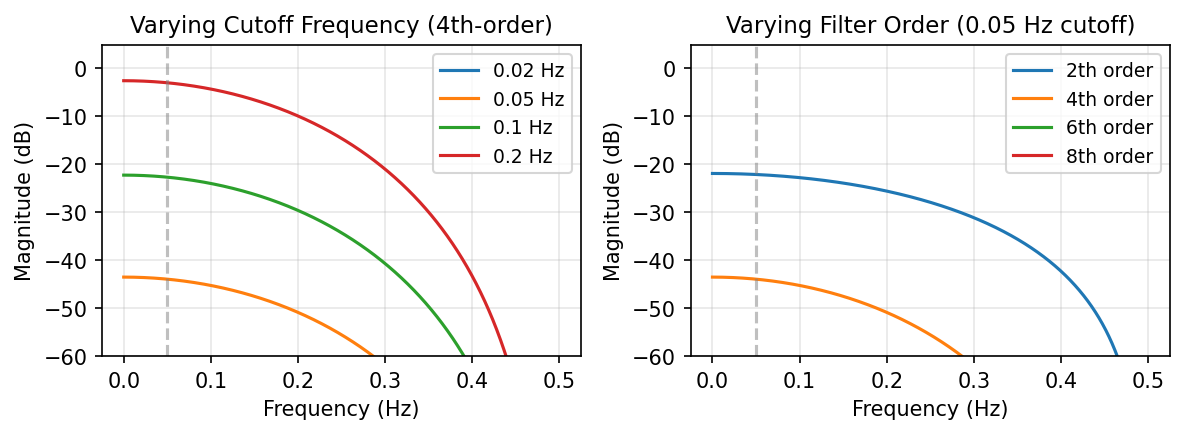

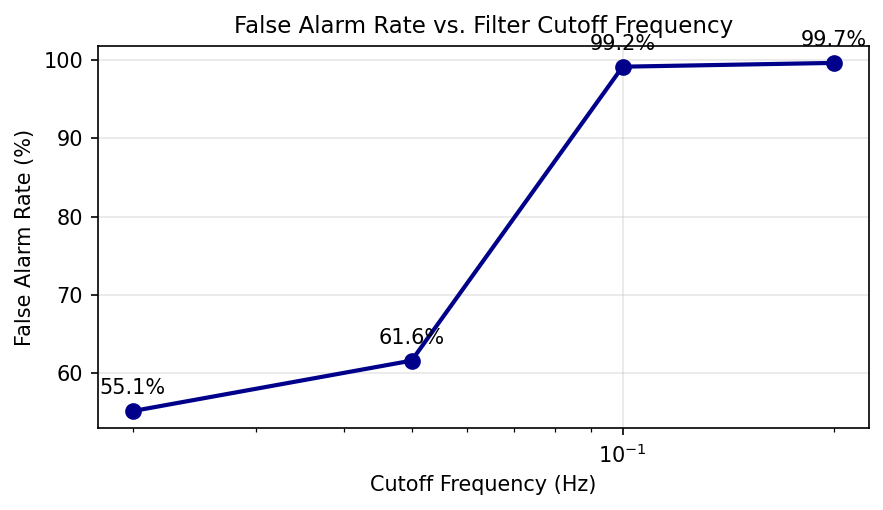

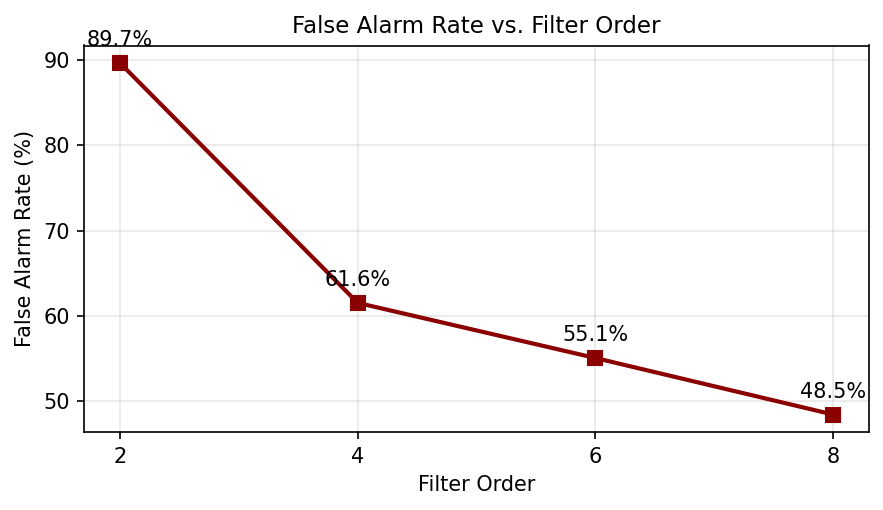

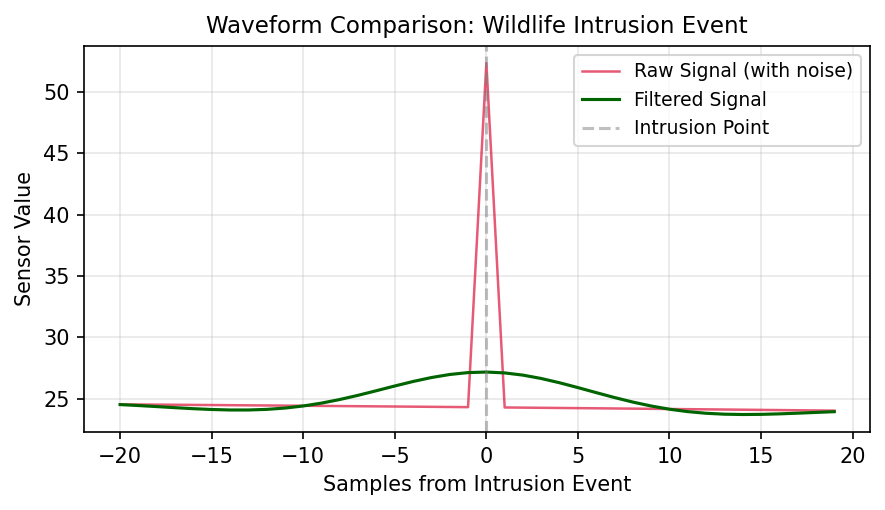

All done


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

# Global Configuration
np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# 1. Data Loading and Dataset Construction
n_samples = 2400
data_url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"

try:
    raw_sensor = pd.read_csv(data_url)
    raw_values = raw_sensor['value'].iloc[:3000].values
    clean_signal = np.interp(
        np.linspace(0, len(raw_values)-1, n_samples),
        np.arange(len(raw_values)),
        raw_values
    )
    print("Successfully loaded real-world NAB industrial sensor data")
except Exception as e:
    print(f"Online loading failed, fallback to synthetic signal: {e}")
    time = np.linspace(0, 4 * np.pi, n_samples)
    clean_signal = 20 + 5 * np.sin(time)

# Build dataset
df = pd.DataFrame({
    'timestamp': pd.date_range(start='2026-07-01', periods=n_samples, freq='T'),
    'clean_signal': clean_signal,
    'dirty_signal': clean_signal.copy(),
    'label': 0  # 0: Normal, 1: Circuit noise, 2: Wildlife intrusion
})

# Inject circuit noise (samples 800-1399)
noise = np.random.normal(0, 3.5, 600)
df.loc[800:1399, 'dirty_signal'] += noise
df.loc[800:1399, 'label'] = 1

# Inject wildlife intrusion pulses
animal_moments = [300, 700, 1600, 2100]
for idx in animal_moments:
    df.loc[idx, 'dirty_signal'] += 28.0
    df.loc[idx, 'label'] = 2

# 2. Butterworth Filter Function
def butter_lowpass_filter(data, cutoff_freq=0.05, sampling_freq=1.0, order=4):
    nyquist = 0.5 * sampling_freq
    normal_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

# 3. Autoencoder Model
class TimeSeriesAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 6)
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# 4. Training and Evaluation Pipeline
def train_and_evaluate(signal_series, labels, animal_events, window_size=20, name="Model"):
    torch.manual_seed(42)
    np.random.seed(42)

    # Standardization (fit on normal data only)
    scaler = StandardScaler()
    sig_arr = np.asarray(signal_series)
    normal_mask = labels == 0
    scaler.fit(sig_arr[normal_mask].reshape(-1, 1))
    scaled_data = scaler.transform(sig_arr.reshape(-1, 1)).flatten()

    # Sliding window
    X = []
    for i in range(len(scaled_data) - window_size):
        X.append(scaled_data[i: i + window_size])
    X = np.array(X)

    # Window labels
    aligned_labels = np.array([
        np.max(labels[i : i + window_size])
        for i in range(len(labels) - window_size)
    ])
    
    # Train/validation split (normal windows only)
    normal_windows = X[aligned_labels == 0]
    np.random.shuffle(normal_windows)
    split_idx = int(len(normal_windows) * 0.8)
    X_train = normal_windows[:split_idx]
    X_val = normal_windows[split_idx:]

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_all_tensor = torch.tensor(X, dtype=torch.float32)

    # Training
    model = TimeSeriesAutoencoder(input_dim=window_size)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    model.train()
    for epoch in range(100):
        permutation = torch.randperm(X_train_tensor.size()[0])
        for i in range(0, X_train_tensor.size()[0], 32):
            indices = permutation[i:i+32]
            batch_x = X_train_tensor[indices]
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_all_tensor)
        mse_errors = torch.mean((X_all_tensor - preds) ** 2, dim=1).numpy()
        
        val_tensor = torch.tensor(X_val, dtype=torch.float32)
        val_preds = model(val_tensor)
        val_mse = torch.mean((val_tensor - val_preds) ** 2, dim=1).numpy()

    # Threshold from validation set
    threshold = np.percentile(val_mse, 97.5)
    
    # 1. False alarm rate in circuit noise region
    circuit_idx = np.where(aligned_labels == 1)[0]
    false_alarms = np.sum(mse_errors[circuit_idx] > threshold)
    total_circuit_windows = len(circuit_idx)
    false_alarm_rate = (false_alarms / total_circuit_windows) * 100

    # 2. Event-level detection rate
    event_det_count = 0
    for idx in animal_events:
        win_start = max(0, idx - window_size + 1)
        win_end = min(idx, len(aligned_labels)-1)
        if np.any(mse_errors[win_start:win_end+1] > threshold):
            event_det_count += 1
    event_det_rate = (event_det_count / len(animal_events)) * 100

    # Print report
    print(f"\n=== {name} Evaluation Report ===")
    print(f"Threshold: {threshold:.6f}")
    print(f"False alarms: {false_alarms} / {total_circuit_windows} ({false_alarm_rate:.2f}%)")
    print(f"Detection rate: {event_det_count} / {len(animal_events)} ({event_det_rate:.2f}%)")

    return mse_errors, threshold, aligned_labels, false_alarm_rate, event_det_rate

# 5. Core Experiment 
print("="*60)
print("Core Controlled Experiment")
print("="*60)

# Direct AI (no filter)
mse_raw, thresh_raw, labels_aligned, fa_rate_raw, det_rate_raw = train_and_evaluate(
    df['dirty_signal'], df['label'].values, animal_moments, 
    name="Direct AI (No Filter)"
)

# EE-Enhanced AI
df['filtered_signal'] = butter_lowpass_filter(df['dirty_signal'], cutoff_freq=0.05, order=4)
mse_filtered, thresh_filtered, _, fa_rate_filtered, det_rate_filtered = train_and_evaluate(
    df['filtered_signal'], df['label'].values, animal_moments,
    name="EE-Enhanced AI (0.05Hz, 4th-order)"
)

# 6. Ablation Studies
print("\n" + "="*60)
print("Ablation Study 1: Cutoff Frequency")
print("="*60)

cutoff_list = [0.02, 0.05, 0.1, 0.2]
cutoff_far = []
for fc in cutoff_list:
    filtered_sig = butter_lowpass_filter(df['dirty_signal'], cutoff_freq=fc, order=4)
    _, _, _, far, edr = train_and_evaluate(
        filtered_sig, df['label'].values, animal_moments,
        name=f"Cutoff = {fc} Hz"
    )
    cutoff_far.append(far)

print("\n" + "="*60)
print("Ablation Study 2: Filter Order")
print("="*60)

order_list = [2, 4, 6, 8]
order_far = []
for ord_num in order_list:
    filtered_sig = butter_lowpass_filter(df['dirty_signal'], cutoff_freq=0.05, order=ord_num)
    _, _, _, far, edr = train_and_evaluate(
        filtered_sig, df['label'].values, animal_moments,
        name=f"{ord_num}th-order"
    )
    order_far.append(far)

#7. Visualization Functions
def plot_reconstruction_comparison():
    time_axis = df['timestamp'].values[:len(mse_raw)]
    event_pos = [min(idx, len(time_axis)-1) for idx in animal_moments]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

    # Top: unfiltered
    ax1.set_yscale('log')
    ax1.plot(time_axis, mse_raw, color='crimson', alpha=0.8, linewidth=0.8)
    ax1.axhline(y=thresh_raw, color='black', linestyle='--', linewidth=1.2, 
                label=f'Threshold ({thresh_raw:.4f})')
    ax1.axvspan(df['timestamp'].iloc[800], df['timestamp'].iloc[1399], 
                color='gold', alpha=0.2, label='Circuit Noise Region')
    ax1.scatter(time_axis[event_pos], mse_raw[event_pos], 
                color='royalblue', marker='^', s=60, zorder=5, label='Wildlife Intrusion')
    ax1.set_title(f'Without Filtering: {fa_rate_raw:.1f}% False Alarm Rate', color='crimson', fontweight='bold')
    ax1.set_ylabel('MSE Reconstruction Loss (log)')
    ax1.legend(loc='upper right', framealpha=0.9)
    ax1.grid(True, alpha=0.3, which='both')

    # Bottom: filtered
    ax2.set_yscale('log')
    ax2.plot(time_axis, mse_filtered, color='darkgreen', alpha=0.8, linewidth=0.8)
    ax2.axhline(y=thresh_filtered, color='black', linestyle='--', linewidth=1.2,
                label=f'Threshold ({thresh_filtered:.4f})')
    ax2.axvspan(df['timestamp'].iloc[800], df['timestamp'].iloc[1399], 
                color='gold', alpha=0.2, label='Circuit Noise Region')
    ax2.scatter(time_axis[event_pos], mse_filtered[event_pos], 
                color='royalblue', marker='^', s=60, zorder=5, label='Wildlife Intrusion')
    ax2.set_title(f'With 0.05 Hz 4th-Order Filter: {fa_rate_filtered:.1f}% False Alarm Rate', 
                  color='darkgreen', fontweight='bold')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('MSE Reconstruction Loss (log)')
    ax2.legend(loc='upper right', framealpha=0.9)
    ax2.grid(True, alpha=0.3, which='both')

    plt.suptitle('Impact of EE Signal Preprocessing on Anomaly Detection', fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def plot_filter_response():
    fs = 1.0
    w = np.linspace(0, 0.5, 1000)
    freq = w * fs

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    # Left: varying cutoff
    for fc in [0.02, 0.05, 0.1, 0.2]:
        b, a = signal.butter(4, fc/(fs/2), 'low')
        _, h = signal.freqz(b, worN=w*2*np.pi)
        ax1.plot(freq, 20*np.log10(np.abs(h)), label=f'{fc} Hz')
    ax1.axvline(0.05, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title('Varying Cutoff Frequency (4th-order)')
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-60, 5)

    # Right: varying order
    for n in [2, 4, 6, 8]:
        b, a = signal.butter(n, 0.05/(fs/2), 'low')
        _, h = signal.freqz(b, worN=w*2*np.pi)
        ax2.plot(freq, 20*np.log10(np.abs(h)), label=f'{n}th order')
    ax2.axvline(0.05, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title('Varying Filter Order (0.05 Hz cutoff)')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-60, 5)

    plt.tight_layout()
    plt.show()


def plot_ablation_curves():
    # Cutoff frequency ablation
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(cutoff_list, cutoff_far, 'o-', color='darkblue', linewidth=2, markersize=7)
    ax.set_xlabel('Cutoff Frequency (Hz)')
    ax.set_ylabel('False Alarm Rate (%)')
    ax.set_title('False Alarm Rate vs. Filter Cutoff Frequency')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    for x, y in zip(cutoff_list, cutoff_far):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
    plt.tight_layout()
    plt.show()

    # Filter order ablation
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(order_list, order_far, 's-', color='darkred', linewidth=2, markersize=7)
    ax.set_xlabel('Filter Order')
    ax.set_ylabel('False Alarm Rate (%)')
    ax.set_title('False Alarm Rate vs. Filter Order')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(order_list)
    for x, y in zip(order_list, order_far):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,8), ha='center')
    plt.tight_layout()
    plt.show()


def plot_intrusion_waveform():
    idx = 1600  # representative intrusion event
    window = slice(idx-20, idx+20)
    t = np.arange(-20, 20)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(t, df['dirty_signal'].values[window], label='Raw Signal (with noise)', 
            color='crimson', alpha=0.7, linewidth=1.2)
    ax.plot(t, df['filtered_signal'].values[window], label='Filtered Signal', 
            color='darkgreen', linewidth=1.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='Intrusion Point')
    ax.set_xlabel('Samples from Intrusion Event')
    ax.set_ylabel('Sensor Value')
    ax.set_title('Waveform Comparison: Wildlife Intrusion Event')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generate all figures
print("\n" + "="*60)
print("Generating academic visualization figures...")
print("="*60)

plot_reconstruction_comparison()
plot_filter_response()
plot_ablation_curves()
plot_intrusion_waveform()

print("All done")